In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

print("Feature names:", iris.feature_names)
print("Target names:", iris.target_names)

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']


In [3]:
X = X[:, [0, 1]]

# Setosa = 1, Non-Setosa = -1
y_binary = np.where(y == 0, 1, -1)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
svm = SVC(kernel="linear", C=1.0)

svm.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [7]:
y_pred = svm.predict(X_test_scaled)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Non-Setosa", "Setosa"]
))


Accuracy: 0.9666666666666667

Classification Report:
              precision    recall  f1-score   support

  Non-Setosa       0.95      1.00      0.98        20
      Setosa       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.98      0.95      0.96        30
weighted avg       0.97      0.97      0.97        30



In [8]:
w = svm.coef_[0]
b = svm.intercept_[0]

print("Weight vector:", w)
print("Bias:", b)

# Decision boundary:
# w0*x + w1*y + b = 0
#
# Margin boundaries:
# w0*x + w1*y + b = +1
# w0*x + w1*y + b = -1

Weight vector: [-2.11605556  1.53255624]
Bias: -1.4446568562854267


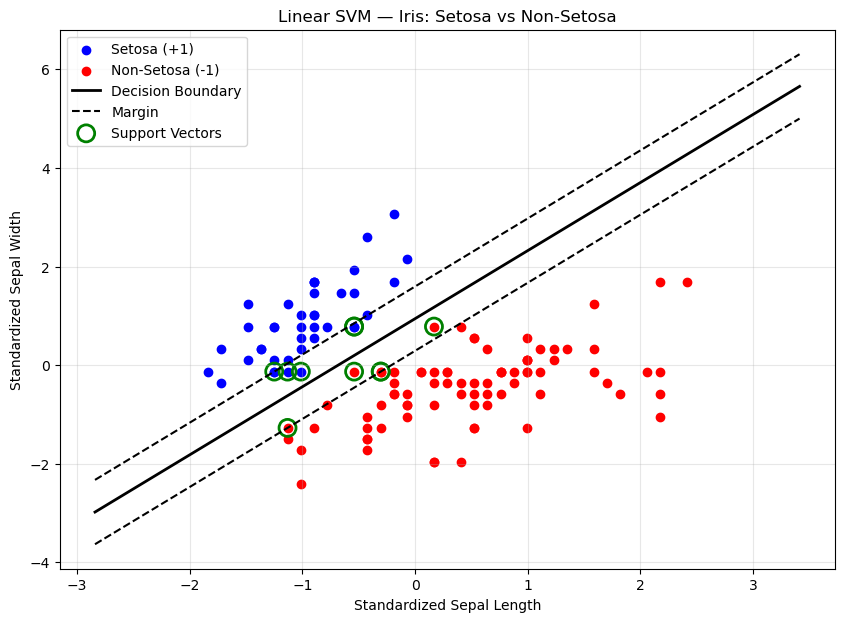

In [9]:
plt.figure(figsize=(10, 7))

# Plot training points
plt.scatter(
    X_train_scaled[y_train == 1, 0],
    X_train_scaled[y_train == 1, 1],
    color="blue",
    label="Setosa (+1)"
)

plt.scatter(
    X_train_scaled[y_train == -1, 0],
    X_train_scaled[y_train == -1, 1],
    color="red",
    label="Non-Setosa (-1)"
)

# Create x-axis values
x_min = X_train_scaled[:, 0].min() - 1
x_max = X_train_scaled[:, 0].max() + 1

xx = np.linspace(x_min, x_max, 500)

# Decision boundary
yy = -(w[0] * xx + b) / w[1]

# Positive margin
yy_margin_positive = -(w[0] * xx + b - 1) / w[1]

# Negative margin
yy_margin_negative = -(w[0] * xx + b + 1) / w[1]

plt.plot(
    xx,
    yy,
    "k-",
    linewidth=2,
    label="Decision Boundary"
)

plt.plot(
    xx,
    yy_margin_positive,
    "k--",
    linewidth=1.5,
    label="Margin"
)

plt.plot(
    xx,
    yy_margin_negative,
    "k--",
    linewidth=1.5
)

# Highlight support vectors
plt.scatter(
    svm.support_vectors_[:, 0],
    svm.support_vectors_[:, 1],
    s=150,
    facecolors="none",
    edgecolors="green",
    linewidths=2,
    label="Support Vectors"
)

plt.xlabel("Standardized Sepal Length")
plt.ylabel("Standardized Sepal Width")
plt.title("Linear SVM — Iris: Setosa vs Non-Setosa")
plt.legend()
plt.grid(alpha=0.3)
plt.show()